# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [2]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [3]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8495,2.3270,216.9600,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,glycine_held,-0.0612
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
glycine_held,H,glycine_held,e,2598.06,0.0393 
water,H,glycine_held,e,2511.865,0.041515
water,e,glycine_held,H,2511.865,0.041515
"""
components = ["water", "glycine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[353.94 294.07079841359604; 294.07079841359604 216.96]
[2.8014570000000003e-10 2.5642285e-10; 2.5642285e-10 2.327e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2511.865, 2511.865, 2598.06]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.041515, 0.041515, 0.0393]
kij = -0.06119999999999992
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0            0.0507466
   2 │      274.488          0.0558804
   3 │      278.976          0.06115
   4 │      283.464          0.0665294
   5 │      287.952          0.0719968
   6 │      292.439          0.0775349
   7 │      296.927          0.0831296
   8 │      301.415          0.0887706
   9 │      305.903          0.09445
  10 │      310.391          0.100162
  11 │      314.879          0.105903
  12 │      319.367          0.111671
  13 │      323.855          0.117464
  14 │      328.342          0.123283
  15 │      332.83           0.129126
  16 │      337.318          0.134996
  17 │      341.806          0.140892
  18 │      346.294          0.146818
  19 │      350.782          0.152773
  20 │      355.27           0.158761
  21 │      359.758          0.164784
  22 │      364.245         

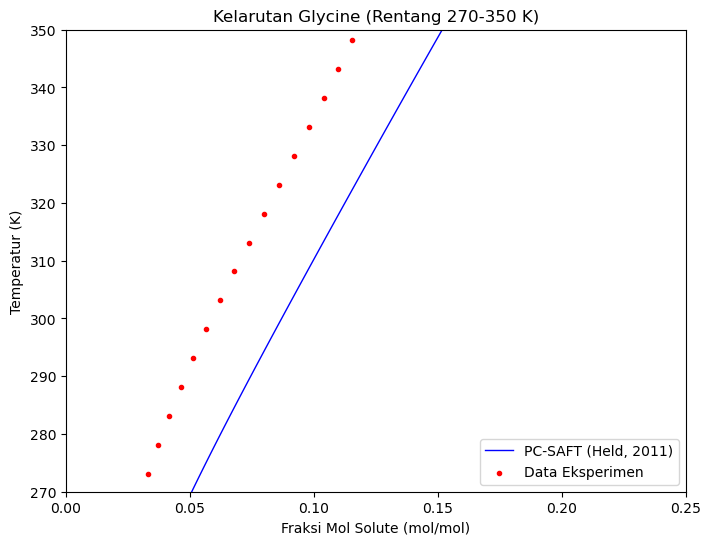

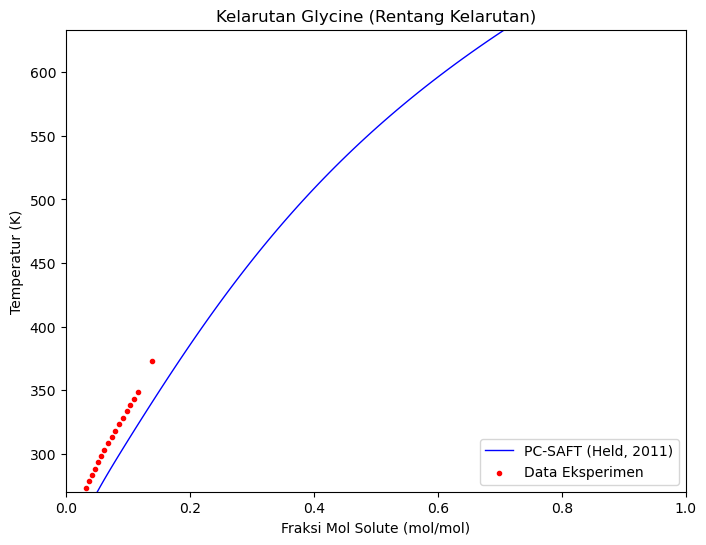

In [15]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model1.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, 633.518)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [56]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [40]:
aard_p   = calculate_AAD(model1, "sol_glycine.csv", solubility_held)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.054335      65.0622 
278.1500    0.037053      0.060171      62.3926 
283.1500    0.041506      0.066150      59.3741 
288.1500    0.046246      0.072240      56.2083 
293.1500    0.051285      0.078417      52.9041 
298.1500    0.056592      0.084662      49.6015 
303.1500    0.062114      0.090962      46.4431 
308.1500    0.067843      0.097306      43.4278 
313.1500    0.073729      0.103689      40.6338 
318.1500    0.079745      0.110105      38.0713 
323.1500    0.085803      0.116553      35.8376 
328.1500    0.091941      0.123033      33.8171 
333.1500    0.097997      0.129543      32.1918 
338.1500    0.103991      0.136087      30.8634 
343.1500    0.109812      0.142664      29.9166 
348.1500    0.115482      0.149277      29.2644 
373.1500    0.138849      0.182979      31.7829 
AARD = 43.3996%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


43.39957125327416

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [5]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,glycine_gclow,0.0000296035176
water,glycine_gcmid,0.0000296035176
water,glycine_gcup,0.0000296035176
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
"""
components_low = ["water", "glycine_gclow"]
components_mid = ["water", "glycine_gcmid"]
components_up = ["water", "glycine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low       X_Mid       X_Up        
     │ Float64       Float64     Float64     Float64     
─────┼───────────────────────────────────────────────────
   1 │      270.0    0.00707105  0.00154585  0.00033733
   2 │      271.575  0.00770935  0.00168985  0.000372349
   3 │      273.151  0.00840521  0.0018458   0.000410555
   4 │      274.726  0.00916452  0.0020146   0.000452197
   5 │      276.301  0.00999394  0.00219721  0.000497543
   6 │      277.877  0.010901    0.0023947   0.000546878
   7 │      279.452  0.0118944   0.00260819  0.000600507
   8 │      281.028  0.0129838   0.0028389   0.000658753
   9 │      282.603  0.0141805   0.00308815  0.000721964
  10 │      284.178  0.0154974   0.00335737  0.000790507
  11 │      285.754  0.0169494   0.00364811  0.000864778
  12 │      287.329  0.0185535   0.00396204  0.000945195
  13 │      288.904  0.0203295   0.00430098  0.00103221
  14 │      290.48   0.0223      0.004

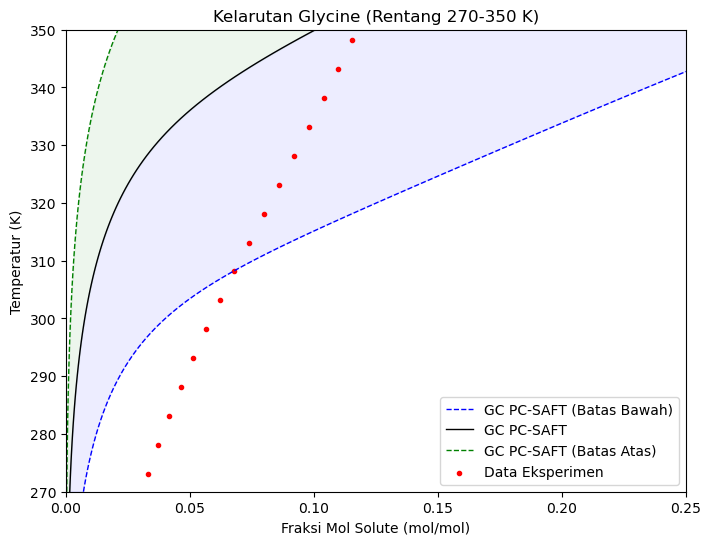

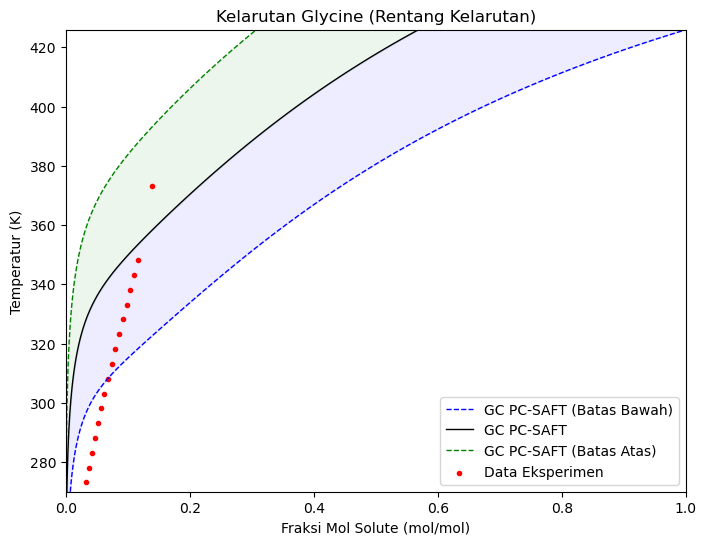

In [6]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [59]:
aard_p   = calculate_AAD(model2_low, "sol_glycine.csv", solubility_gclow)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.008405      74.4669 
278.1500    0.037053      0.011067      70.1325 
283.1500    0.041506      0.014624      64.7680 
288.1500    0.046246      0.019456      57.9290 
293.1500    0.051285      0.026159      48.9926 
298.1500    0.056592      0.035639      37.0247 
303.1500    0.062114      0.049090      20.9684 
308.1500    0.067843      0.067418      0.6269  
313.1500    0.073729      0.090128      22.2411 
318.1500    0.079745      0.115467      44.7957 
323.1500    0.085803      0.141952      65.4386 
328.1500    0.091941      0.168926      83.7336 
333.1500    0.097997      0.196250      100.2617
338.1500    0.103991      0.223992      115.3953
343.1500    0.109812      0.252298      129.7553
348.1500    0.115482      0.281334      143.6173
373.1500    0.138849      0.443727      219.5750
AARD = 76.4543%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


76.45425075438693

In [60]:
aard_p   = calculate_AAD(model2_mid, "sol_glycine.csv", solubility_gcmid)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.001846      94.3929 
278.1500    0.037053      0.002431      93.4404 
283.1500    0.041506      0.003179      92.3402 
288.1500    0.046246      0.004135      91.0578 
293.1500    0.051285      0.005355      89.5583 
298.1500    0.056592      0.006912      87.7862 
303.1500    0.062114      0.008905      85.6636 
308.1500    0.067843      0.011468      83.0958 
313.1500    0.073729      0.014789      79.9411 
318.1500    0.079745      0.019131      76.0095 
323.1500    0.085803      0.024866      71.0193 
328.1500    0.091941      0.032507      64.6438 
333.1500    0.097997      0.042693      56.4342 
338.1500    0.103991      0.056048      46.1033 
343.1500    0.109812      0.072834      33.6742 
348.1500    0.115482      0.092671      19.7531 
373.1500    0.138849      0.214416      54.4238 
AARD = 71.7257%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


71.72573221323097

In [61]:
aard_p   = calculate_AAD(model2_up, "sol_glycine.csv", solubility_gcup)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.000411      98.7528 
278.1500    0.037053      0.000556      98.4998 
283.1500    0.041506      0.000745      98.2047 
288.1500    0.046246      0.000990      97.8600 
293.1500    0.051285      0.001303      97.4586 
298.1500    0.056592      0.001703      96.9904 
303.1500    0.062114      0.002210      96.4419 
308.1500    0.067843      0.002850      95.7994 
313.1500    0.073729      0.003655      95.0430 
318.1500    0.079745      0.004665      94.1501 
323.1500    0.085803      0.005932      93.0868 
328.1500    0.091941      0.007520      91.8205 
333.1500    0.097997      0.009515      90.2901 
338.1500    0.103991      0.012028      88.4336 
343.1500    0.109812      0.015206      86.1531 
348.1500    0.115482      0.019244      83.3363 
373.1500    0.138849      0.063434      54.3144 
AARD = 91.5668%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


91.5668087941086

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [7]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8492,2.2140,238.6085,2,2 
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,glycine_held,0.0000296035176
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
glycine_held,H,glycine_held,e,3012.118,0.267058
water,H,glycine_held,e,2718.894,0.107377
water,e,glycine_held,H,2718.894,0.107377
"""
components = ["water", "glycine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 290.59953948138354; 290.59953948138354 238.6085]
[2.8014570000000003e-10 2.5077285000000003e-10; 2.5077285000000003e-10 2.214e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2718.894, 2718.894, 3012.118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.107377, 0.107377, 0.267058]
kij = 2.960351760006308e-5
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0           0.00236719
   2 │      274.488         0.00281144
   3 │      278.976         0.00332434
   4 │      283.464         0.00391486
   5 │      287.952         0.00459311
   6 │      292.439         0.0053705
   7 │      296.927         0.00626
   8 │      301.415         0.00727635
   9 │      305.903         0.00843633
  10 │      310.391         0.00975912
  11 │      314.879         0.0112666
  12 │      319.367         0.0129836
  13 │      323.855         0.0149386
  14 │      328.342         0.0171635
  15 │      332.83          0.0196939
  16 │      337.318         0.0225689
  17 │      341.806         0.0258303
  18 │      346.294         0.029521
  19 │      350.782         0.0336823
  20 │      355.27          0.0383506
  21 │      359.758         0.0435529
  22 │      364.245         

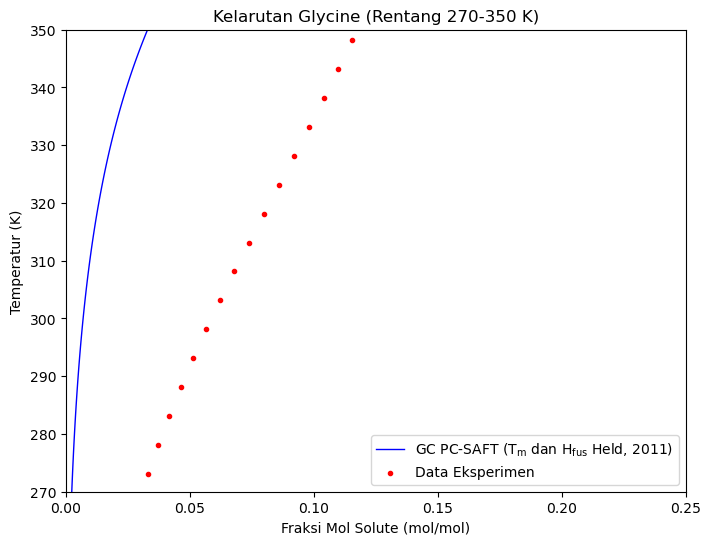

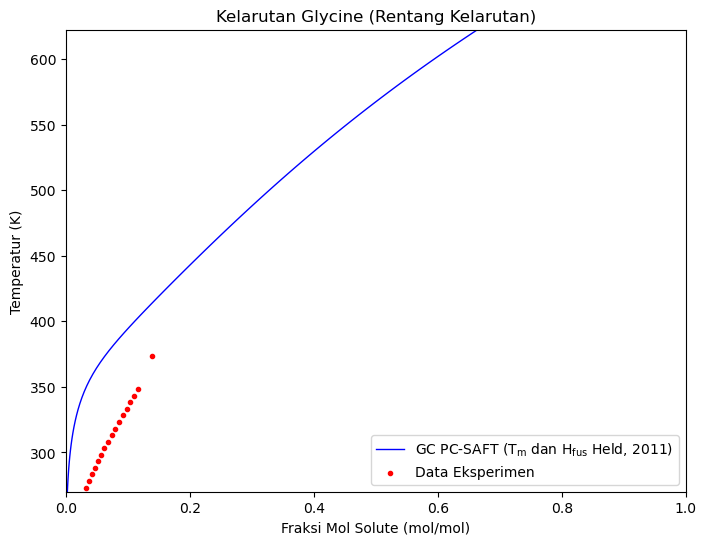

In [8]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model3.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, 622.376)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [67]:
aard_p   = calculate_AAD(model3, "sol_glycine.csv", solubility_held)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.002672      91.8822 
278.1500    0.037053      0.003224      91.2978 
283.1500    0.041506      0.003871      90.6740 
288.1500    0.046246      0.004625      89.9985 
293.1500    0.051285      0.005504      89.2688 
298.1500    0.056592      0.006524      88.4724 
303.1500    0.062114      0.007707      87.5926 
308.1500    0.067843      0.009077      86.6207 
313.1500    0.073729      0.010663      85.5383 
318.1500    0.079745      0.012496      84.3302 
323.1500    0.085803      0.014615      82.9672 
328.1500    0.091941      0.017062      81.4423 
333.1500    0.097997      0.019887      79.7066 
338.1500    0.103991      0.023143      77.7453 
343.1500    0.109812      0.026889      75.5139 
348.1500    0.115482      0.031183      72.9978 
373.1500    0.138849      0.062288      55.1394 
AARD = 83.0111%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


83.01107006075004

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [9]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,glycine_gclow,-0.0612
water,glycine_gcmid,-0.0612
water,glycine_gcup,-0.0612
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
"""
components_low = ["water", "glycine_gclow"]
components_mid = ["water", "glycine_gcmid"]
components_up = ["water", "glycine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low     X_Mid      X_Up       
     │ Float64       Float64   Float64    Float64    
─────┼───────────────────────────────────────────────
   1 │      270.0    0.131029  0.0356672  0.00672053
   2 │      271.575  0.135539  0.0383195  0.00729889
   3 │      273.151  0.140065  0.0411005  0.00792119
   4 │      274.726  0.144605  0.0440066  0.00859035
   5 │      276.301  0.149161  0.0470332  0.00930944
   6 │      277.877  0.153733  0.0501747  0.0100817
   7 │      279.452  0.158323  0.0534252  0.0109103
   8 │      281.028  0.162931  0.0567779  0.011799
   9 │      282.603  0.167558  0.060226   0.0127512
  10 │      284.178  0.172206  0.0637626  0.0137708
  11 │      285.754  0.176876  0.0673807  0.0148614
  12 │      287.329  0.181568  0.0710738  0.0160269
  13 │      288.904  0.186284  0.0748357  0.0172712
  14 │      290.48   0.191026  0.0786606  0.0185981
  15 │      292.055  0.195794  0.0825433  0.0200114
  16 

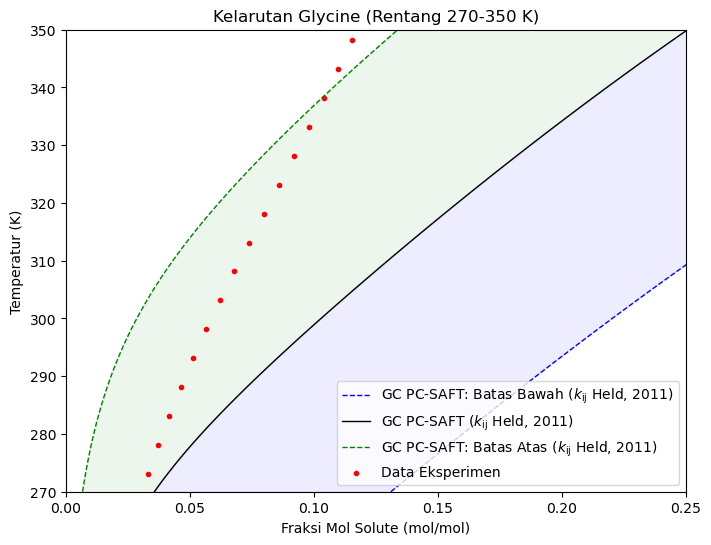

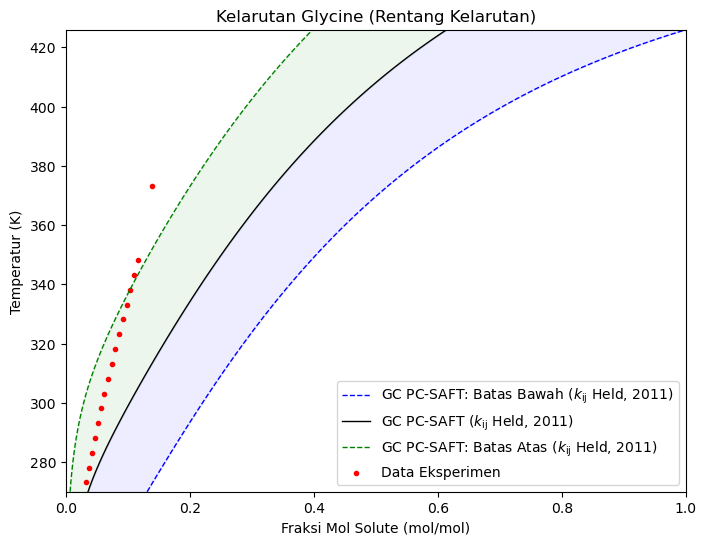

In [10]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [72]:
aard_p   = calculate_AAD(model4_low, "sol_glycine.csv", solubility_gclow)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.140063      325.4948


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


278.1500    0.037053      0.154528      317.0445
283.1500    0.041506      0.169170      307.5765
288.1500    0.046246      0.184023      297.9197
293.1500    0.051285      0.199124      288.2684
298.1500    0.056592      0.214516      279.0583
303.1500    0.062114      0.230242      270.6760
308.1500    0.067843      0.246348      263.1129
313.1500    0.073729      0.262881      256.5489
318.1500    0.079745      0.279895      250.9873
323.1500    0.085803      0.297443      246.6565
328.1500    0.091941      0.315585      243.2479
333.1500    0.097997      0.334386      241.2222
338.1500    0.103991      0.353916      240.3327
343.1500    0.109812      0.374255      240.8147
348.1500    0.115482      0.395488      242.4676
373.1500    0.138849      0.519075      273.8413
AARD = 269.7218%


269.7217776349521

In [73]:
aard_p   = calculate_AAD(model4_mid, "sol_glycine.csv", solubility_gcmid)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.041099      24.8548 
278.1500    0.037053      0.050731      36.9138 
283.1500    0.041506      0.061445      48.0366 
288.1500    0.046246      0.073026      57.9073 
293.1500    0.051285      0.085273      66.2725 
298.1500    0.056592      0.098028      73.2192 
303.1500    0.062114      0.111183      78.9987 
308.1500    0.067843      0.124676      83.7708 
313.1500    0.073729      0.138475      87.8157 
318.1500    0.079745      0.152574      91.3270 
323.1500    0.085803      0.166979      94.6065 
328.1500    0.091941      0.181710      97.6378 
333.1500    0.097997      0.196793      100.8164
338.1500    0.103991      0.212261      104.1143
343.1500    0.109812      0.228151      107.7656
348.1500    0.115482      0.244505      111.7254
373.1500    0.138849      0.335021      141.2845
AARD = 82.7686%


82.76864757786835

In [74]:
aard_p   = calculate_AAD(model4_up, "sol_glycine.csv", solubility_gcup)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.007921      75.9372 
278.1500    0.037053      0.010221      72.4147 
283.1500    0.041506      0.013097      68.4446 
288.1500    0.046246      0.016665      63.9640 
293.1500    0.051285      0.021047      58.9618 
298.1500    0.056592      0.026357      53.4258 
303.1500    0.062114      0.032688      47.3739 
308.1500    0.067843      0.040085      40.9157 
313.1500    0.073729      0.048532      34.1755 
318.1500    0.079745      0.057958      27.3210 
323.1500    0.085803      0.068251      20.4569 
328.1500    0.091941      0.079286      13.7647 
333.1500    0.097997      0.090947      7.1936  
338.1500    0.103991      0.103142      0.8170  
343.1500    0.109812      0.115802      5.4551  
348.1500    0.115482      0.128885      11.6061 
373.1500    0.138849      0.200320      44.2717 
AARD = 38.0294%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


38.029364469254524

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [11]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,glycine_gclow,0
water,glycine_gcmid,0
water,glycine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
"""
components_low = ["water", "glycine_gclow"]
components_mid = ["water", "glycine_gcmid"]
components_up = ["water", "glycine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low       X_Mid       X_Up        
     │ Float64       Float64     Float64     Float64     
─────┼───────────────────────────────────────────────────
   1 │      270.0    0.00708254  0.0015481   0.000337811
   2 │      271.575  0.00772192  0.00169231  0.000372877
   3 │      273.151  0.00841897  0.00184847  0.000411134
   4 │      274.726  0.0091796   0.0020175   0.000452831
   5 │      276.301  0.0100105   0.00220037  0.000498236
   6 │      277.877  0.0109192   0.00239813  0.000547636
   7 │      279.452  0.0119143   0.00261192  0.000601334
   8 │      281.028  0.0130057   0.00284294  0.000659655
   9 │      282.603  0.0142047   0.00309254  0.000722946
  10 │      284.178  0.0155241   0.00336213  0.000791578
  11 │      285.754  0.0169789   0.00365327  0.000865942
  12 │      287.329  0.0185862   0.00396763  0.000946461
  13 │      288.904  0.0203657   0.00430704  0.00103358
  14 │      290.48   0.0223402   0.00

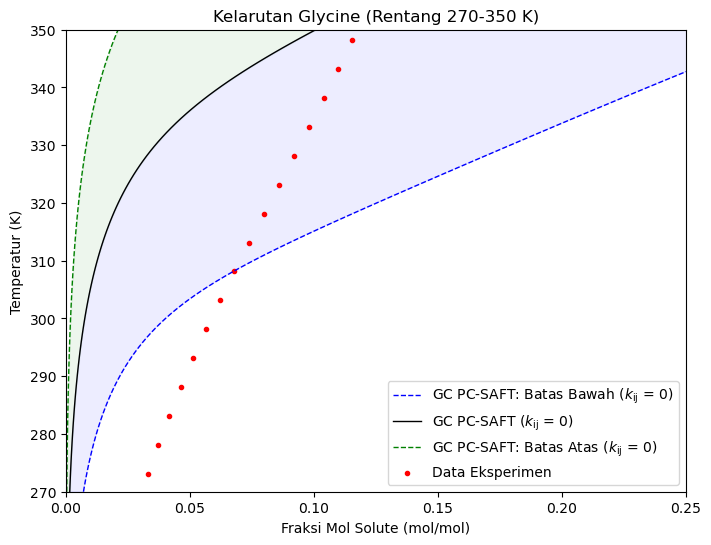

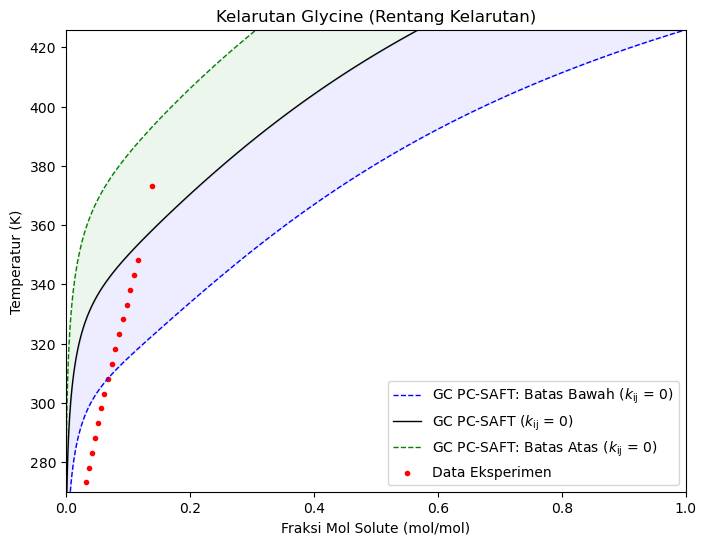

In [12]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model5_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [97]:
aard_p   = calculate_AAD(model5_low, "sol_glycine.csv", solubility_gclow)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.008419      74.4251 
278.1500    0.037053      0.011085      70.0827 
283.1500    0.041506      0.014649      64.7077 
288.1500    0.046246      0.019491      57.8545 
293.1500    0.051285      0.026207      48.8986 
298.1500    0.056592      0.035707      36.9047 
303.1500    0.062114      0.049183      20.8182 
308.1500    0.067843      0.067535      0.4537  
313.1500    0.073729      0.090258      22.4172 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


318.1500    0.079745      0.115597      44.9579 
323.1500    0.085803      0.142074      65.5812 
328.1500    0.091941      0.169040      83.8570 
333.1500    0.097997      0.196354      100.3684
338.1500    0.103991      0.224089      115.4879
343.1500    0.109812      0.252387      129.8361
348.1500    0.115482      0.281416      143.6879
373.1500    0.138849      0.443777      219.6109
AARD = 76.4676%


76.46763565541798

In [98]:
aard_p   = calculate_AAD(model5_mid, "sol_glycine.csv", solubility_gcmid)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.001848      94.3848 
278.1500    0.037053      0.002434      93.4310 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


283.1500    0.041506      0.003184      92.3293 
288.1500    0.046246      0.004141      91.0452 
293.1500    0.051285      0.005363      89.5436 
298.1500    0.056592      0.006922      87.7691 
303.1500    0.062114      0.008917      85.6434 
308.1500    0.067843      0.011485      83.0717 
313.1500    0.073729      0.014811      79.9122 
318.1500    0.079745      0.019159      75.9743 
323.1500    0.085803      0.024904      70.9759 
328.1500    0.091941      0.032556      64.5903 
333.1500    0.097997      0.042757      56.3687 
338.1500    0.103991      0.056128      46.0260 
343.1500    0.109812      0.072928      33.5885 
348.1500    0.115482      0.092773      19.6649 
373.1500    0.138849      0.214501      54.4850 
AARD = 71.6943%


71.69433786350689

In [99]:
aard_p   = calculate_AAD(model5_up, "sol_glycine.csv", solubility_gcup)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.000411      98.7511 
278.1500    0.037053      0.000557      98.4977 
283.1500    0.041506      0.000746      98.2023 
288.1500    0.046246      0.000991      97.8571 
293.1500    0.051285      0.001305      97.4553 
298.1500    0.056592      0.001705      96.9865 
303.1500    0.062114      0.002213      96.4374 
308.1500    0.067843      0.002853      95.7940 
313.1500    0.073729      0.003659      95.0368 
318.1500    0.079745      0.004671      94.1428 
323.1500    0.085803      0.005939      93.0783 
328.1500    0.091941      0.007530      91.8104 
333.1500    0.097997      0.009527      90.2781 
338.1500    0.103991      0.012043      88.4193 
343.1500    0.109812      0.015224      86.1358 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


348.1500    0.115482      0.019268      83.3154 
373.1500    0.138849      0.063505      54.2635 
AARD = 91.5566%


91.55658350801752

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [13]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,glycine_gclow,0.000013527940174729
water,glycine_gcmid,0.000013527940174729
water,glycine_gcup,0.000013527940174729
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
"""
components_low = ["water", "glycine_gclow"]
components_mid = ["water", "glycine_gcmid"]
components_up = ["water", "glycine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low       X_Mid       X_Up        
     │ Float64       Float64     Float64     Float64     
─────┼───────────────────────────────────────────────────
   1 │      270.0    0.00707729  0.00154707  0.000337591
   2 │      271.575  0.00771618  0.00169119  0.000372636
   3 │      273.151  0.00841268  0.00184725  0.000410869
   4 │      274.726  0.0091727   0.00201617  0.000452541
   5 │      276.301  0.0100029   0.00219893  0.00049792
   6 │      277.877  0.0109109   0.00239656  0.00054729
   7 │      279.452  0.0119052   0.00261021  0.000600956
   8 │      281.028  0.0129957   0.0028411   0.000659243
   9 │      282.603  0.0141936   0.00309053  0.000722497
  10 │      284.178  0.0155119   0.00335996  0.000791088
  11 │      285.754  0.0169654   0.00365091  0.00086541
  12 │      287.329  0.0185712   0.00396507  0.000945882
  13 │      288.904  0.0203491   0.00430427  0.00103295
  14 │      290.48   0.0223218   0.00467

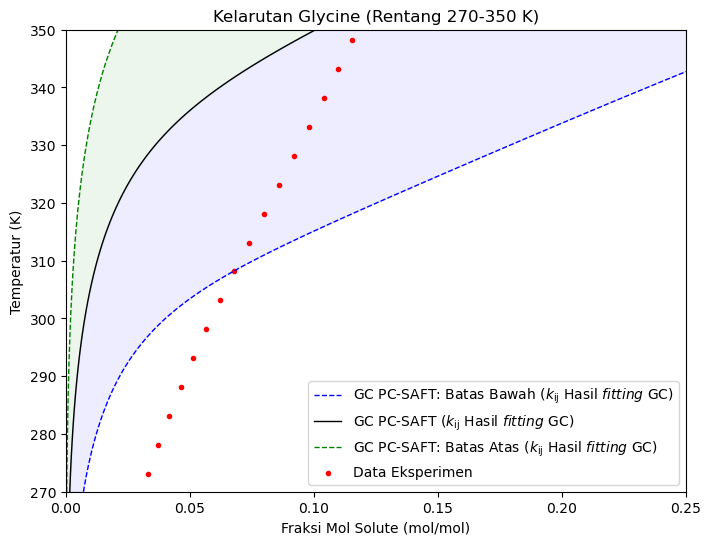

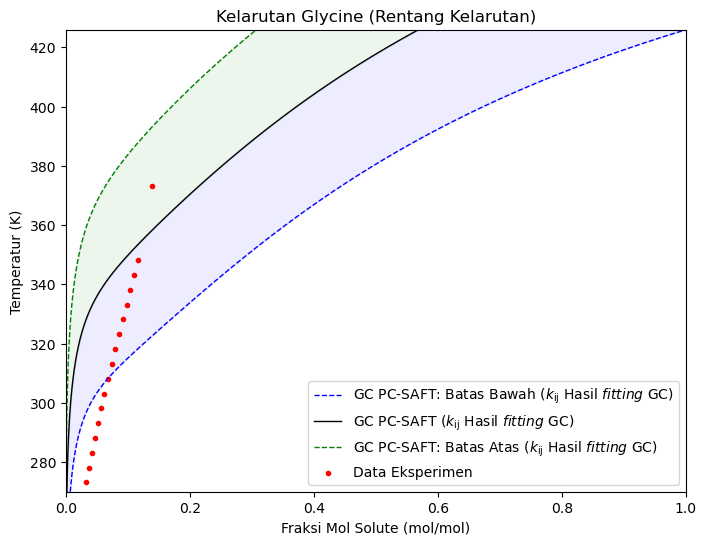

In [14]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_glycine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [105]:
aard_p   = calculate_AAD(model6_low, "sol_glycine.csv", solubility_gclow)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.008412      74.4442 
278.1500    0.037053      0.011077      70.1055 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


283.1500    0.041506      0.014637      64.7353 
288.1500    0.046246      0.019475      57.8885 
293.1500    0.051285      0.026185      48.9416 
298.1500    0.056592      0.035676      36.9596 
303.1500    0.062114      0.049140      20.8869 
308.1500    0.067843      0.067482      0.5329  
313.1500    0.073729      0.090198      22.3367 
318.1500    0.079745      0.115538      44.8838 
323.1500    0.085803      0.142018      65.5161 
328.1500    0.091941      0.168988      83.8006 
333.1500    0.097997      0.196306      100.3197
338.1500    0.103991      0.224045      115.4456
343.1500    0.109812      0.252346      129.7992
348.1500    0.115482      0.281378      143.6556
373.1500    0.138849      0.443754      219.5945
AARD = 76.4615%


76.46153179503546

In [106]:
aard_p   = calculate_AAD(model6_mid, "sol_glycine.csv", solubility_gcmid)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.032918      0.001847      94.3885 
278.1500    0.037053      0.002432      93.4353 
283.1500    0.041506      0.003182      92.3343 
288.1500    0.046246      0.004139      91.0509 
293.1500    0.051285      0.005359      89.5503 
298.1500    0.056592      0.006917      87.7769 
303.1500    0.062114      0.008912      85.6526 
308.1500    0.067843      0.011477      83.0827 
313.1500    0.073729      0.014801      79.9254 
318.1500    0.079745      0.019146      75.9904 
323.1500    0.085803      0.024887      70.9958 
328.1500    0.091941      0.032534      64.6147 
333.1500    0.097997      0.042728      56.3986 
338.1500    0.103991      0.056092      46.0613 
343.1500    0.109812      0.072885      33.6277 
348.1500    0.115482      0.092726      19.7052 
373.1500    0.138849      0.214462      54.4570 
AARD = 71.7087%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


71.70868884447069

In [107]:
aard_p   = calculate_AAD(model6_up, "sol_glycine.csv", solubility_gcup)


=== AAD: sol_glycine.csv ===
Clapeyron Estimator  exp           calc          ARD%    


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


273.1500    0.032918      0.000411      98.7519 
278.1500    0.037053      0.000556      98.4987 
283.1500    0.041506      0.000746      98.2034 
288.1500    0.046246      0.000990      97.8584 
293.1500    0.051285      0.001304      97.4568 
298.1500    0.056592      0.001704      96.9883 
303.1500    0.062114      0.002212      96.4395 
308.1500    0.067843      0.002852      95.7965 
313.1500    0.073729      0.003657      95.0397 
318.1500    0.079745      0.004668      94.1461 
323.1500    0.085803      0.005936      93.0822 
328.1500    0.091941      0.007525      91.8151 
333.1500    0.097997      0.009522      90.2836 
338.1500    0.103991      0.012036      88.4258 
343.1500    0.109812      0.015216      86.1437 
348.1500    0.115482      0.019257      83.3250 
373.1500    0.138849      0.063472      54.2868 
AARD = 91.5613%


91.56125753906088